In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d 
from sklearn.model_selection import train_test_split as tts 
from sklearn.svm import SVC 
from matplotlib.colors import ListedColormap


In [2]:
from sklearn.datasets._samples_generator import make_circles 
X,y = make_circles(100,factor=.1,noise=.1 )

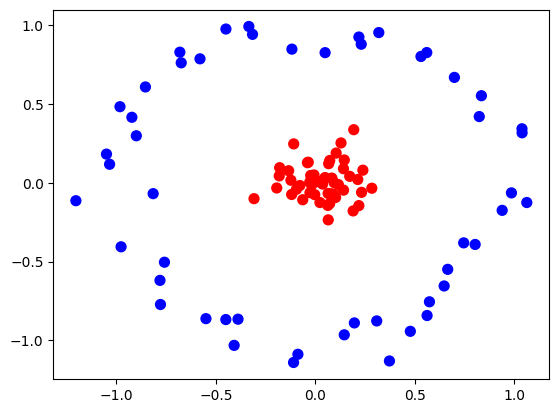

In [4]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='bwr')

In [5]:
X_train,X_test,y_train,y_test = tts(X,y,test_size=0.2)

In [6]:
clf = SVC(kernel='linear')
clf.fit(X_train,y_train.ravel())
y_pred= clf.predict(X_test)


In [7]:
from sklearn.metrics import accuracy_score 
accuracy_score(y_test,y_pred)

0.55

In [8]:
zero_one_colormap = ListedColormap(('blue','red'))
def plot_decision_boundary(X,y,clf):
    X_set,y_set = X,y 
    X1,X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1,
                                  stop= X_set[:,0].max()+1,
                                  step=0.01),
                        np.arange(start=X_set[:,1].min()-1,
                                  stop=X_set[:,1].max()+1,
                                  step = 0.01))
    plt.contourf(X1,X2,clf.predict(np.array([X1.ravel(),X2.ravel()]).T).reshape(X1.shape),
                 alpha= 0.75,
                 cmap = zero_one_colormap)
    plt.xlim(X1.min(),X1.max())
    plt.ylim(X2.min(),X2.max())
    for i,j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j,0], X_set[y_set == j,1],
                    c= (zero_one_colormap)(i),label = j)
    
    plt.title('SVM')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_5239/243849501.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0], X_set[y_set == j,1],


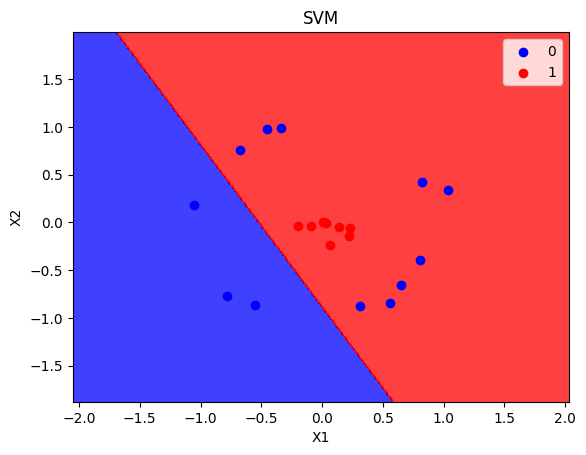

In [9]:
plot_decision_boundary(X_test,y_test,clf)

/tmp/ipykernel_5239/243849501.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0], X_set[y_set == j,1],


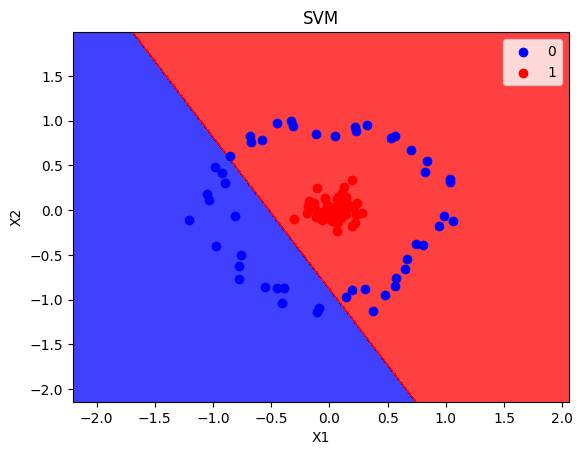

In [10]:
plot_decision_boundary(X,y,clf)

In [13]:
def _plot3d(X,y):
    r = np.exp(-(X**2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter(X[:,0],X[:,1],r,c=y,s=100,cmap='bwr',)
    return ax
    # not working in latest updates of matplot library

<Axes3D: >

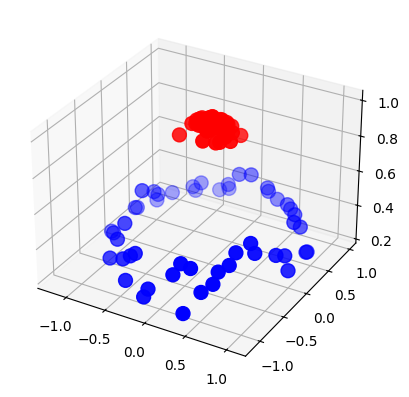

In [14]:
_plot3d(X,y)

In [18]:
clf1 = SVC(kernel='rbf')
clf1.fit(X_train,y_train)
y_pred = clf1.predict(X_test)


In [19]:
accuracy_score(y_test,y_pred)

1.0

/tmp/ipykernel_5239/243849501.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0], X_set[y_set == j,1],


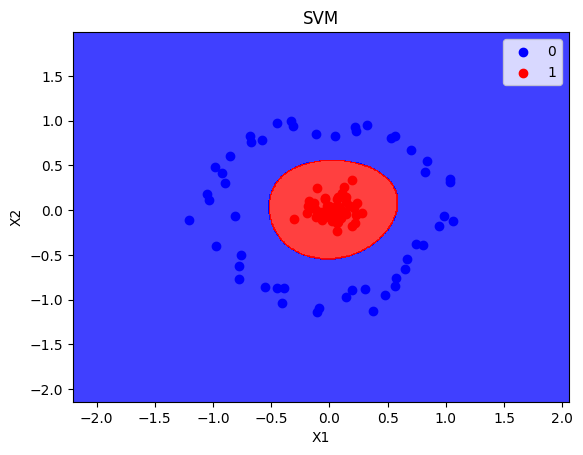

In [20]:
plot_decision_boundary(X,y,clf1)

In [27]:
clf2 = SVC(kernel='poly',degree=2)

In [28]:
clf2.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
y_pred = clf2.predict(X_test)

In [30]:
accuracy_score(y_test,y_pred)


1.0

/tmp/ipykernel_5239/243849501.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0], X_set[y_set == j,1],


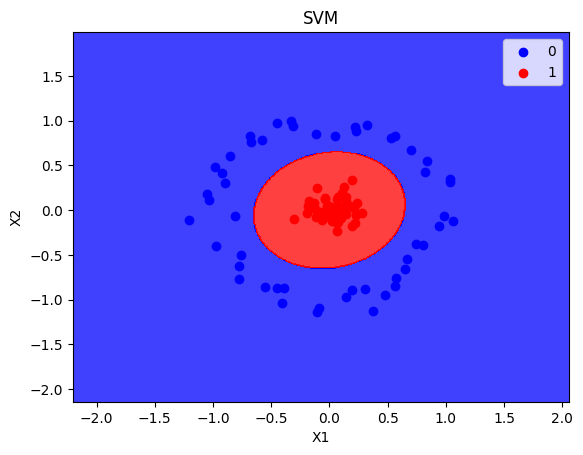

In [31]:
plot_decision_boundary(X,y,clf2)